# Parallel Trends Analysis for Staggered Difference-in-Differences
---

**Research question:** Did EU cohesion policy (targeted via marginalizacja designation) affect economic development and/or populist voting in Polish gminas?

**Design:** Staggered DiD exploiting the fact that gminas entered the marginalizacja list at different times:
- **2014 cohort:** 627 gminas designated in the original 2014 delimitacja
- **2018 cohort:** 128 gminas added in the 2018 update (not on 2014 list)
- **Never treated:** gminas never on any marginalizacja list

**Parallel trends assumption:** Pre-treatment trajectories of treated and control gminas should be similar.

### Data requirements
| Data | Source | Status |
|------|--------|--------|
| EU funding panel | Pipeline output | ✓ |
| Revenue per capita | BDL var 76976 | ✓ |
| Marginalizacja lists | Ministry/IGiPZ PAN | ✓ |
| Electoral data (PKW) | pkw.gov.pl | ◻ Add when ready |
| Full BDL panel (68 vars) | BDL API | ◻ Add when ready |

## 0. Configuration

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- PATHS (update to your local paths) ---
import os
REPO = r"C:\Users\jarem\OneDrive - London School of Economics\YEAR 2\1. Policy paper\policy-paper-repo"

PATH_MASTER = os.path.join(REPO, r"data\clean\treatment\eu_flows\final\eu_funds_gmina_panel_master.csv")
PATH_BY_PERIOD = os.path.join(REPO, r"data\clean\treatment\eu_flows\final\eu_funds_gmina_panel_by_period.csv")
PATH_REVENUE = os.path.join(REPO, r"code\downloaders_all\bdl\bdl_output\variables\revenue_per_capita.csv")
PATH_MARG = os.path.join(REPO, r"data\clean\treatment\regional_policy_status\marginalizacja_list_755_with_historical_flags.csv")
PATH_CITIES = os.path.join(REPO, r"data\clean\treatment\regional_policy_status\miasta_srednie_139_tracace_funkcje.csv")

# Electoral data — uncomment when available
# PATH_PKW = os.path.join(REPO, r"data\clean\outcome\pkw_gmina_panel.csv")

print("Paths configured.")


Paths configured.


## 1. Load and Merge Data

In [13]:
# --- Load EU funding panel ---
master = pd.read_csv(PATH_MASTER, encoding='utf-8-sig')
master['gmina_id'] = master['gmina_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(7)
master['gmina_id_6'] = master['gmina_id'].str[:6]

print(f"EU funding panel: {master.shape[0]:,} rows, {master['gmina_id'].nunique()} gminas, years {master['Year'].min()}-{master['Year'].max()}")

# --- Load revenue per capita ---
rev = pd.read_csv(PATH_REVENUE, encoding='utf-8-sig')
# BDL uses different IDs — match by name+voivodeship
# For now, use the revenue already merged into the master panel if available
# Or load separately and merge via name bridge (built in pipeline session)

# --- Load marginalizacja list ---
marg = pd.read_csv(PATH_MARG, encoding='utf-8-sig')
print(f"Marginalizacja list: {len(marg)} gminas")
print(f"Columns: {list(marg.columns)}")
print(marg.head(3))


EU funding panel: 53,281 rows, 2481 gminas, years 2007-2026
Marginalizacja list: 755 gminas
Columns: ['teryt_6digit', 'voivodship_pl', 'powiat_pl', 'gmina_name', 'marginalizacja_2021_2027', 'bdl_unit_id_approx', 'medium_city_losing_functions', 'voivodship_code', 'added_in_2018_update', 'dropped_2018_readded_2021']
   teryt_6digit voivodship_pl      powiat_pl gmina_name  \
0         20103  dolnośląskie  bolesławiecki   Gromadka   
1         20305  dolnośląskie      głogowski     Pęcław   
2         20401  dolnośląskie       górowski       Góra   

   marginalizacja_2021_2027  bdl_unit_id_approx  medium_city_losing_functions  \
0                         1         20103000000                             0   
1                         1         20305000000                             0   
2                         1         20401000000                             0   

   voivodship_code  added_in_2018_update  dropped_2018_readded_2021  
0                2                     1            

## 2. Build Treatment Groups

Three cohorts based on when a gmina was first designated as marginalized:

| Cohort | Definition | N (approx) |
|--------|-----------|-------------|
| **2014 cohort** | On 2014 list AND `added_in_2018_update == 0` | ~539 |
| **2018 cohort** | `added_in_2018_update == 1` | ~128 |
| **Never treated** | Not on any marginalizacja list | ~1,724 |
| **Dropped & readded** | `dropped_2018_readded_2021 == 1` | ~88 |

In [14]:
# Prepare marginalizacja treatment flags
marg['teryt_6'] = marg['teryt_6digit'].astype(str).str.zfill(6)

# Build treatment assignment
# Cohort 1: persistently marginalized since 2014 (on 2014, stayed on 2018, on 2021-27)
# These have added_in_2018_update == 0 AND dropped_2018_readded_2021 == 0
marg['cohort'] = 'on_2021_list'  # default

if 'added_in_2018_update' in marg.columns:
    marg.loc[marg['added_in_2018_update'] == 1, 'cohort'] = '2018_cohort'
    marg.loc[marg['added_in_2018_update'] == 0, 'cohort'] = '2014_cohort'

if 'dropped_2018_readded_2021' in marg.columns:
    marg.loc[marg['dropped_2018_readded_2021'] == 1, 'cohort'] = 'dropped_readded'

print("Treatment cohorts from marginalizacja list:")
print(marg['cohort'].value_counts())

# Create a clean lookup: gmina_id_6 → cohort + treatment_year
treatment = marg[['teryt_6', 'cohort']].copy()
treatment['treatment_year'] = treatment['cohort'].map({
    '2014_cohort': 2014,
    '2018_cohort': 2018,
    'dropped_readded': 2014,  # originally treated in 2014
    'on_2021_list': 2014,     # default for unclassified
})

treatment = treatment.rename(columns={'teryt_6': 'gmina_id_6'})
treatment = treatment.drop_duplicates('gmina_id_6')
print(f"\nTreatment lookup: {len(treatment)} gminas")


Treatment cohorts from marginalizacja list:
cohort
2014_cohort        539
2018_cohort        128
dropped_readded     88
Name: count, dtype: int64

Treatment lookup: 755 gminas


## 3. Merge Treatment Status onto Panel

In [15]:
# Merge treatment status
panel = master.merge(treatment, on='gmina_id_6', how='left')

# Gminas NOT on any marginalizacja list = never treated
panel['cohort'] = panel['cohort'].fillna('never_treated')
panel['treatment_year'] = panel['treatment_year'].fillna(9999).astype(int)  # 9999 = never

# Binary treatment indicator (ever treated)
panel['ever_treated'] = (panel['cohort'] != 'never_treated').astype(int)

# Post-treatment indicator (relative to gmina's own treatment year)
panel['post'] = (panel['Year'] >= panel['treatment_year']).astype(int)
panel.loc[panel['treatment_year'] == 9999, 'post'] = 0

# Event time (years relative to treatment)
panel['event_time'] = panel['Year'] - panel['treatment_year']
panel.loc[panel['treatment_year'] == 9999, 'event_time'] = np.nan

print("Panel with treatment status:")
print(f"  Total rows: {len(panel):,}")
print(f"  Gminas: {panel['gmina_id'].nunique()}")
print(f"\nCohort distribution:")
print(panel.groupby('cohort')['gmina_id'].nunique())

print(f"\nTreatment × Post crosstab (gmina-years):")
print(pd.crosstab(panel['ever_treated'], panel['post'], margins=True))


Panel with treatment status:
  Total rows: 53,281
  Gminas: 2481

Cohort distribution:
cohort
2014_cohort         539
2018_cohort         128
dropped_readded      88
never_treated      1726
Name: gmina_id, dtype: int64

Treatment × Post crosstab (gmina-years):
post              0     1    All
ever_treated                    
0             37800     0  37800
1              5842  9639  15481
All           43642  9639  53281


## 4. Outcome Variables

Using available data. Add more outcomes as BDL/PKW data becomes available.

In [16]:
# --- Outcome 1: EU funding per capita (from pipeline) ---
# Already in the panel as EU_subsidy_per_capita_PLN

# --- Outcome 2: Revenue per capita (proxy for economic development) ---
# Already merged if your pipeline included PATH_POPULATION
# If not, we'll construct it

# --- Define outcomes to analyse ---
outcomes = {}

if 'EU_subsidy_per_capita_PLN' in panel.columns:
    outcomes['EU Subsidy per Capita (PLN)'] = 'EU_subsidy_per_capita_PLN'

if 'total_value_per_capita_PLN' in panel.columns:
    outcomes['Total Project Value per Capita (PLN)'] = 'total_value_per_capita_PLN'

# Add log versions for better distributional properties
for label, col in list(outcomes.items()):
    panel[f'log_{col}'] = np.log1p(panel[col].fillna(0))
    outcomes[f'Log {label}'] = f'log_{col}'

print(f"Outcomes available: {len(outcomes)}")
for label, col in outcomes.items():
    valid = panel[col].notna().sum()
    print(f"  {label} ({col}): {valid:,} non-null observations")


Outcomes available: 4
  EU Subsidy per Capita (PLN) (EU_subsidy_per_capita_PLN): 49,360 non-null observations
  Total Project Value per Capita (PLN) (total_value_per_capita_PLN): 49,360 non-null observations
  Log EU Subsidy per Capita (PLN) (log_EU_subsidy_per_capita_PLN): 53,281 non-null observations
  Log Total Project Value per Capita (PLN) (log_total_value_per_capita_PLN): 53,281 non-null observations


## 5. Parallel Trends — Visual Inspection

The core assumption: treated and control gminas followed similar trajectories before treatment.

### 5a. Raw means by cohort

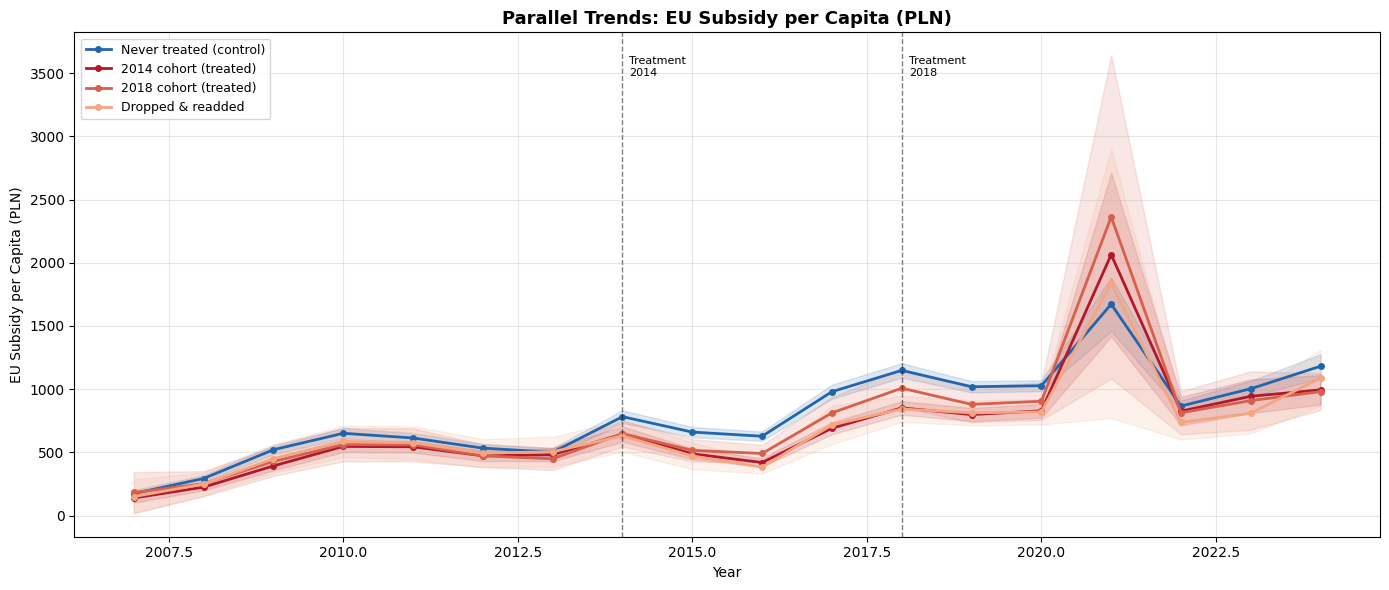

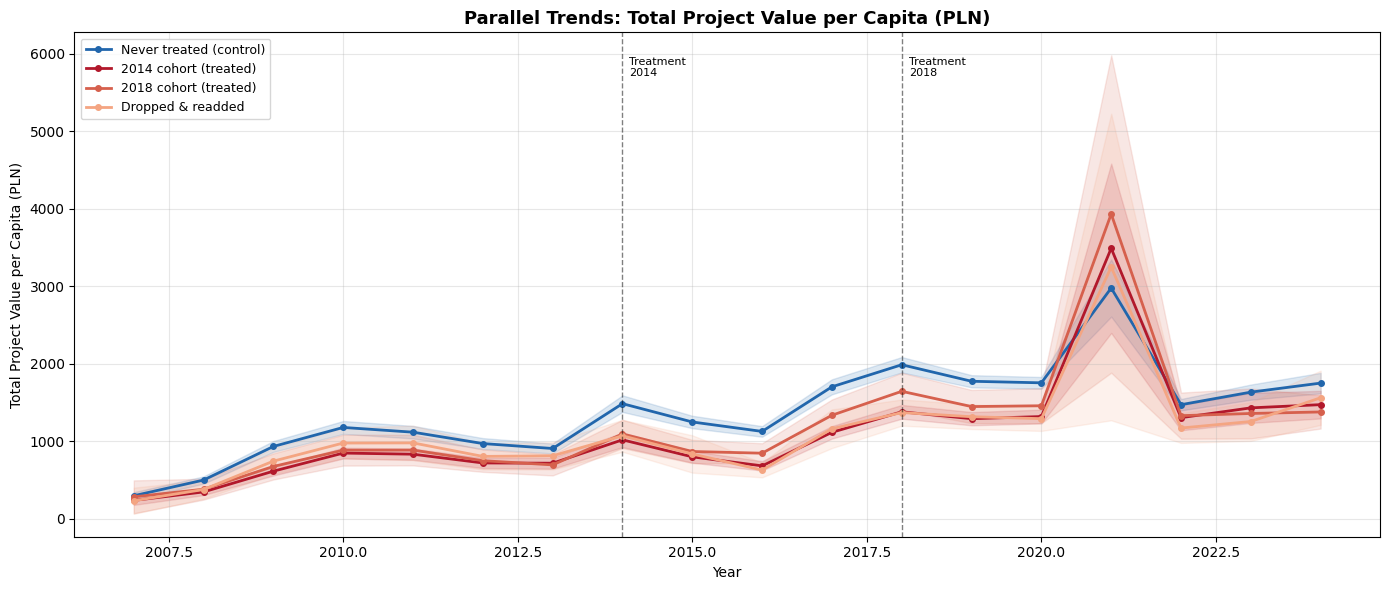

In [17]:
def plot_parallel_trends(panel, outcome_col, outcome_label, 
                         treatment_years=[2014, 2018], 
                         year_range=(2007, 2024)):
    """
    Plot mean outcome by cohort over time with treatment year markers.
    """
    # Filter years
    df = panel[(panel['Year'] >= year_range[0]) & (panel['Year'] <= year_range[1])].copy()
    
    # Group means by cohort × year
    cohort_means = df.groupby(['cohort', 'Year'])[outcome_col].agg(['mean', 'std', 'count']).reset_index()
    cohort_means['se'] = cohort_means['std'] / np.sqrt(cohort_means['count'])
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = {
        'never_treated': '#2166ac',
        '2014_cohort': '#b2182b', 
        '2018_cohort': '#d6604d',
        'dropped_readded': '#f4a582',
        'on_2021_list': '#999999',
    }
    labels = {
        'never_treated': 'Never treated (control)',
        '2014_cohort': '2014 cohort (treated)',
        '2018_cohort': '2018 cohort (treated)',
        'dropped_readded': 'Dropped & readded',
        'on_2021_list': 'On 2021 list (unclassified)',
    }
    
    for cohort in ['never_treated', '2014_cohort', '2018_cohort', 'dropped_readded']:
        sub = cohort_means[cohort_means['cohort'] == cohort]
        if sub.empty:
            continue
        ax.plot(sub['Year'], sub['mean'], 'o-', 
                color=colors.get(cohort, 'grey'),
                label=labels.get(cohort, cohort),
                linewidth=2, markersize=4)
        ax.fill_between(sub['Year'], 
                        sub['mean'] - 1.96 * sub['se'],
                        sub['mean'] + 1.96 * sub['se'],
                        alpha=0.15, color=colors.get(cohort, 'grey'))
    
    # Treatment year markers
    for ty in treatment_years:
        ax.axvline(x=ty, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(ty + 0.1, ax.get_ylim()[1] * 0.95, f'Treatment\n{ty}', 
                fontsize=8, va='top')
    
    ax.set_xlabel('Year')
    ax.set_ylabel(outcome_label)
    ax.set_title(f'Parallel Trends: {outcome_label}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

# Plot for each outcome
for label, col in outcomes.items():
    if 'log' not in label.lower():  # skip log versions for visual
        fig = plot_parallel_trends(panel, col, label)
        plt.show()


### 5b. Event Study Plot (relative to treatment year)

Centers each cohort at t=0 (treatment year) and plots mean outcomes relative to that.

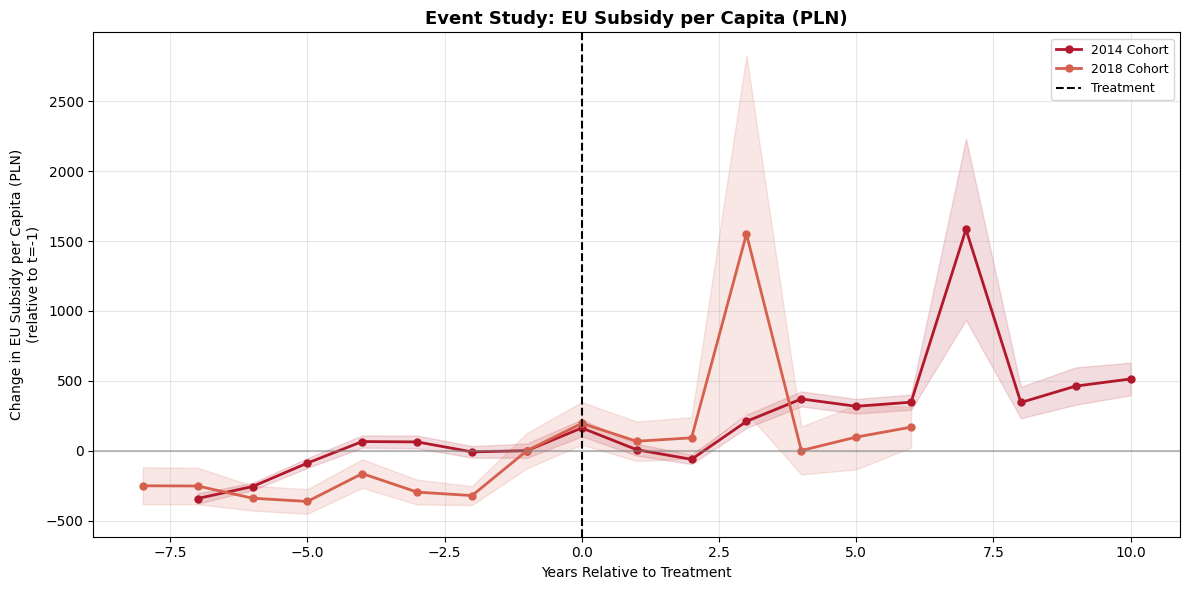

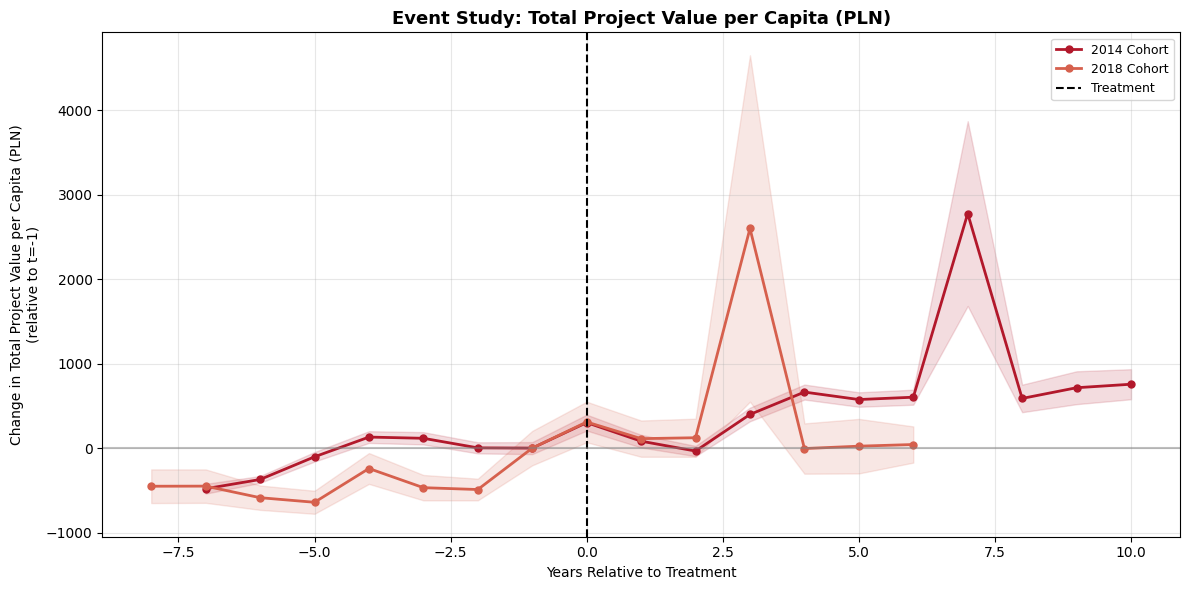

In [18]:
def plot_event_study(panel, outcome_col, outcome_label, 
                     event_window=(-8, 10)):
    """
    Event study plot: outcome relative to treatment year.
    Only includes treated gminas (2014 and 2018 cohorts).
    """
    df = panel[panel['event_time'].notna()].copy()
    df = df[(df['event_time'] >= event_window[0]) & (df['event_time'] <= event_window[1])]
    
    # Normalise to t=-1 (last pre-treatment year)
    baseline = df[df['event_time'] == -1].groupby('cohort')[outcome_col].mean()
    
    event_means = df.groupby(['cohort', 'event_time'])[outcome_col].agg(['mean', 'std', 'count']).reset_index()
    event_means['se'] = event_means['std'] / np.sqrt(event_means['count'])
    
    # Normalise
    for cohort in event_means['cohort'].unique():
        if cohort in baseline.index:
            mask = event_means['cohort'] == cohort
            event_means.loc[mask, 'mean_norm'] = event_means.loc[mask, 'mean'] - baseline[cohort]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {'2014_cohort': '#b2182b', '2018_cohort': '#d6604d', 'dropped_readded': '#f4a582'}
    
    for cohort in ['2014_cohort', '2018_cohort']:
        sub = event_means[event_means['cohort'] == cohort]
        if sub.empty or 'mean_norm' not in sub.columns:
            continue
        ax.plot(sub['event_time'], sub['mean_norm'], 'o-',
                color=colors.get(cohort, 'grey'),
                label=cohort.replace('_', ' ').title(),
                linewidth=2, markersize=5)
        ax.fill_between(sub['event_time'],
                        sub['mean_norm'] - 1.96 * sub['se'],
                        sub['mean_norm'] + 1.96 * sub['se'],
                        alpha=0.15, color=colors.get(cohort, 'grey'))
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Treatment')
    ax.axhline(y=0, color='grey', linestyle='-', alpha=0.5)
    ax.set_xlabel('Years Relative to Treatment')
    ax.set_ylabel(f'Change in {outcome_label}\n(relative to t=-1)')
    ax.set_title(f'Event Study: {outcome_label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

for label, col in outcomes.items():
    if 'log' not in label.lower():
        fig = plot_event_study(panel, col, label)
        plt.show()


## 6. Parallel Trends — Statistical Tests

### 6a. Pre-treatment trend equality test
Tests whether the slope of the outcome differs between treated and control in the pre-treatment period.

In [19]:
def test_parallel_trends(panel, outcome_col, treatment_year=2014, 
                         pre_years=range(2007, 2014)):
    """
    Test H0: pre-treatment trends are the same for treated vs control.
    Uses interaction of group × linear time trend in OLS.
    """
    df = panel[(panel['Year'].isin(pre_years)) & (panel[outcome_col].notna())].copy()
    
    # Simple version: compare slopes
    treated_means = df[df['ever_treated'] == 1].groupby('Year')[outcome_col].mean()
    control_means = df[df['ever_treated'] == 0].groupby('Year')[outcome_col].mean()
    
    # Regress each on time
    from scipy.stats import linregress
    
    results = {}
    for label, means in [('Treated', treated_means), ('Control', control_means)]:
        if len(means) >= 3:
            slope, intercept, r, p, se = linregress(means.index, means.values)
            results[label] = {'slope': slope, 'se': se, 'p': p, 'r2': r**2}
    
    if 'Treated' in results and 'Control' in results:
        slope_diff = results['Treated']['slope'] - results['Control']['slope']
        # Approximate SE of difference
        se_diff = np.sqrt(results['Treated']['se']**2 + results['Control']['se']**2)
        t_stat = slope_diff / se_diff if se_diff > 0 else 0
        p_diff = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(pre_years) - 2))
        
        print(f"Pre-treatment trend test ({outcome_col}, pre-{treatment_year}):")
        print(f"  Treated slope: {results['Treated']['slope']:+.2f} (SE: {results['Treated']['se']:.2f})")
        print(f"  Control slope: {results['Control']['slope']:+.2f} (SE: {results['Control']['se']:.2f})")
        print(f"  Difference:    {slope_diff:+.2f} (SE: {se_diff:.2f})")
        print(f"  t-stat: {t_stat:.3f}, p-value: {p_diff:.4f}")
        if p_diff > 0.05:
            print(f"  ✓ Cannot reject H0: parallel trends (p={p_diff:.3f} > 0.05)")
        else:
            print(f"  ⚠ Reject H0: trends differ (p={p_diff:.3f} < 0.05)")
        print()
    
    return results

# Run for each outcome
for label, col in outcomes.items():
    if 'log' not in label.lower():
        test_parallel_trends(panel, col, treatment_year=2014, pre_years=range(2007, 2014))


Pre-treatment trend test (EU_subsidy_per_capita_PLN, pre-2014):
  Treated slope: +57.93 (SE: 19.90)
  Control slope: +55.48 (SE: 25.83)
  Difference:    +2.45 (SE: 32.61)
  t-stat: 0.075, p-value: 0.9431
  ✓ Cannot reject H0: parallel trends (p=0.943 > 0.05)

Pre-treatment trend test (total_value_per_capita_PLN, pre-2014):
  Treated slope: +86.49 (SE: 32.20)
  Control slope: +105.66 (SE: 47.88)
  Difference:    -19.16 (SE: 57.70)
  t-stat: -0.332, p-value: 0.7533
  ✓ Cannot reject H0: parallel trends (p=0.753 > 0.05)



### 6b. Formal event study regression (OLS with gmina and year FE)

Estimates:
```
Y_it = α_i + δ_t + Σ_k β_k × D_i × 1(t = g_i + k) + ε_it
```
where α_i are gmina FE, δ_t are year FE, D_i = treated, g_i = treatment year, k = event time.

Pre-treatment β_k should be jointly zero (parallel trends).

In [20]:
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    print("Install statsmodels: pip install statsmodels")
    HAS_SM = False

def event_study_regression(panel, outcome_col, outcome_label,
                           event_window=(-7, 8), base_period=-1):
    """
    OLS event study with gmina and year fixed effects.
    Reports coefficients and joint F-test for pre-trends.
    """
    if not HAS_SM:
        print("statsmodels not available")
        return
    
    df = panel[
        (panel['event_time'].notna()) & 
        (panel[outcome_col].notna()) &
        (panel['event_time'] >= event_window[0]) &
        (panel['event_time'] <= event_window[1])
    ].copy()
    
    df['event_time_int'] = df['event_time'].astype(int)
    
    # Create event-time dummies (excluding base period)
    event_times = sorted(df['event_time_int'].unique())
    event_times = [t for t in event_times if t != base_period]
    
    for t in event_times:
        df[f'et_{t}'] = (df['event_time_int'] == t).astype(int)
    
    # Demean by gmina and year (two-way FE via demeaning)
    for col_name in [outcome_col] + [f'et_{t}' for t in event_times]:
        gmina_mean = df.groupby('gmina_id')[col_name].transform('mean')
        year_mean = df.groupby('Year')[col_name].transform('mean')
        overall_mean = df[col_name].mean()
        df[f'{col_name}_dm'] = df[col_name] - gmina_mean - year_mean + overall_mean
    
    # Regression
    et_cols = [f'et_{t}_dm' for t in event_times]
    X = df[et_cols].values
    y = df[f'{outcome_col}_dm'].values
    
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type='HC1')
    
    # Extract coefficients
    coefs = []
    for i, t in enumerate(event_times):
        coefs.append({
            'event_time': t,
            'coef': model.params[i + 1],  # skip constant
            'se': model.bse[i + 1],
            'ci_lo': model.conf_int()[i + 1, 0],
            'ci_hi': model.conf_int()[i + 1, 1],
            'p': model.pvalues[i + 1],
        })
    # Add base period
    coefs.append({'event_time': base_period, 'coef': 0, 'se': 0, 'ci_lo': 0, 'ci_hi': 0, 'p': 1})
    coef_df = pd.DataFrame(coefs).sort_values('event_time')
    
    # Joint F-test for pre-treatment coefficients
    pre_indices = [i + 1 for i, t in enumerate(event_times) if t < 0]
    if pre_indices:
        R = np.zeros((len(pre_indices), len(model.params)))
        for j, idx in enumerate(pre_indices):
            R[j, idx] = 1
        f_test = model.f_test(R)
        print(f"\nJoint F-test for pre-treatment coefficients (β_k = 0 for k < 0):")
        print(f"  F-stat: {f_test.fvalue[0][0]:.3f}")
        print(f"  p-value: {f_test.pvalue:.4f}")
        if f_test.pvalue > 0.05:
            print(f"  ✓ Cannot reject parallel trends (p={f_test.pvalue:.3f})")
        else:
            print(f"  ⚠ Pre-treatment coefficients jointly significant (p={f_test.pvalue:.3f})")
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.errorbar(coef_df['event_time'], coef_df['coef'], 
                yerr=1.96 * coef_df['se'],
                fmt='o-', color='#b2182b', linewidth=2, markersize=6, capsize=3)
    ax.axvline(x=-0.5, color='black', linestyle='--', linewidth=1.5)
    ax.axhline(y=0, color='grey', linestyle='-', alpha=0.5)
    ax.fill_between(coef_df[coef_df['event_time'] < 0]['event_time'],
                     coef_df[coef_df['event_time'] < 0]['ci_lo'],
                     coef_df[coef_df['event_time'] < 0]['ci_hi'],
                     alpha=0.1, color='blue', label='Pre-treatment 95% CI')
    ax.set_xlabel('Years Relative to Treatment', fontsize=11)
    ax.set_ylabel(f'Effect on {outcome_label}', fontsize=11)
    ax.set_title(f'Event Study: {outcome_label}\n(Two-way FE, base period t={base_period})',
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return coef_df, model

# Run event study regression
for label, col in outcomes.items():
    if 'Log' in label:  # use log version for regression
        print(f"\n{'='*60}")
        print(f"EVENT STUDY: {label}")
        print(f"{'='*60}")
        coef_df, model = event_study_regression(panel, col, label)



EVENT STUDY: Log EU Subsidy per Capita (PLN)

Joint F-test for pre-treatment coefficients (β_k = 0 for k < 0):


TypeError: 'float' object is not subscriptable

## 7. Summary Statistics by Treatment Group

In [21]:
def summary_by_group(panel, year=2013):
    """Pre-treatment summary statistics by treatment status."""
    df = panel[panel['Year'] == year].copy()
    
    num_cols = [c for c in ['EU_subsidy_per_capita_PLN', 'total_value_per_capita_PLN', 
                             'population_total', 'EU_subsidy_PLN'] 
                if c in df.columns]
    
    summary = df.groupby('cohort')[num_cols].agg(['mean', 'median', 'std', 'count'])
    
    print(f"\nPre-treatment summary statistics (Year = {year}):")
    print(f"{'='*80}")
    
    for cohort in ['never_treated', '2014_cohort', '2018_cohort', 'dropped_readded']:
        if cohort in df['cohort'].values:
            sub = df[df['cohort'] == cohort]
            print(f"\n{cohort.upper()} (N = {sub['gmina_id'].nunique()} gminas):")
            for col in num_cols:
                vals = sub[col].dropna()
                if len(vals) > 0:
                    print(f"  {col}: mean={vals.mean():,.0f}, median={vals.median():,.0f}, sd={vals.std():,.0f}")

summary_by_group(panel, year=2013)



Pre-treatment summary statistics (Year = 2013):

NEVER_TREATED (N = 1726 gminas):
  EU_subsidy_per_capita_PLN: mean=501, median=307, sd=730
  total_value_per_capita_PLN: mean=904, median=493, sd=1,456
  population_total: mean=18,989, median=9,854, sd=41,411
  EU_subsidy_PLN: mean=12,269,111, median=2,883,700, sd=96,804,862

2014_COHORT (N = 539 gminas):
  EU_subsidy_per_capita_PLN: mean=482, median=317, sd=631
  total_value_per_capita_PLN: mean=715, median=433, sd=873
  population_total: mean=6,666, median=5,494, sd=4,450
  EU_subsidy_PLN: mean=3,183,448, median=1,688,815, sd=4,029,939

2018_COHORT (N = 128 gminas):
  EU_subsidy_per_capita_PLN: mean=449, median=294, sd=523
  total_value_per_capita_PLN: mean=693, median=425, sd=808
  population_total: mean=6,389, median=4,928, sd=4,325
  EU_subsidy_PLN: mean=2,842,552, median=1,450,929, sd=3,603,865

DROPPED_READDED (N = 88 gminas):
  EU_subsidy_per_capita_PLN: mean=505, median=322, sd=597
  total_value_per_capita_PLN: mean=810, median

## 8. Covariate Balance Check

Tests whether treated and control gminas differ on observables before treatment.

In [ ]:
def balance_table(panel, pre_year=2013):
    """Balance table: treated vs control in pre-treatment year."""
    df = panel[panel['Year'] == pre_year].copy()
    
    treated = df[df['ever_treated'] == 1]
    control = df[df['ever_treated'] == 0]
    
    balance_cols = [c for c in ['EU_subsidy_per_capita_PLN', 'population_total',
                                 'EU_subsidy_PLN', 'total_value_per_capita_PLN']
                    if c in df.columns]
    
    print(f"\nBalance Table (pre-treatment year {pre_year}):")
    print(f"{'Variable':<35} {'Treated':>12} {'Control':>12} {'Diff':>10} {'p-value':>10}")
    print("-" * 80)
    
    for col in balance_cols:
        t_mean = treated[col].mean()
        c_mean = control[col].mean()
        diff = t_mean - c_mean
        
        # t-test
        t_vals = treated[col].dropna()
        c_vals = control[col].dropna()
        if len(t_vals) > 1 and len(c_vals) > 1:
            t_stat, p_val = stats.ttest_ind(t_vals, c_vals, equal_var=False)
        else:
            p_val = np.nan
        
        stars = '***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.1 else ''
        print(f"  {col:<33} {t_mean:>12,.0f} {c_mean:>12,.0f} {diff:>+10,.0f} {p_val:>8.4f} {stars}")
    
    print(f"\n  N (treated): {treated['gmina_id'].nunique()}")
    print(f"  N (control): {control['gmina_id'].nunique()}")

balance_table(panel, pre_year=2013)


## 9. Placeholder: Electoral Outcome Analysis

Uncomment and run when PKW data is available.

```python
# Load PKW electoral data
pkw = pd.read_csv(PATH_PKW, encoding='utf-8-sig')
pkw['gmina_id_6'] = pkw['teryt'].astype(str).str.zfill(6)

# Merge onto panel
panel = panel.merge(pkw[['gmina_id_6', 'year', 'pis_share', 'konfederacja_share', 'turnout']], 
                    left_on=['gmina_id_6', 'Year'], right_on=['gmina_id_6', 'year'], how='left')

# Add to outcomes dict
outcomes['PiS Vote Share'] = 'pis_share'
outcomes['Konfederacja Vote Share'] = 'konfederacja_share'
outcomes['Electoral Turnout'] = 'turnout'

# Re-run parallel trends plots and tests
```

## 10. Next Steps

1. **Add BDL outcome variables** (unemployment, migration, demographics) once download completes
2. **Add PKW electoral data** for voting outcomes
3. **Run formal staggered DiD** using Callaway & Sant'Anna (2021) or Sun & Abraham (2021) estimator
4. **Robustness checks:**
   - Equal-split vs population-weighted disaggregation
   - Different treatment definitions (binary vs continuous funding intensity)
   - Spatial spillovers (neighbouring gmina funding)
   - Placebo treatment years
5. **Heterogeneity analysis:**
   - By gmina type (urban/rural/urban-rural)
   - By voivodeship
   - By initial development level (above/below median revenue)

### Recommended R packages for staggered DiD:
```r
# Callaway & Sant'Anna (2021)
library(did)
att_gt <- att_gt(yname = "pis_share", tname = "Year", idname = "gmina_id",
                 gname = "treatment_year", data = panel)

# Sun & Abraham (2021)  
library(fixest)
feols(pis_share ~ sunab(treatment_year, Year) | gmina_id + Year, data = panel)
```